In [1]:
import meld 
import numpy as np
import os
import pandas as pd
from pathlib import Path
import scanpy as sc
from sklearn.metrics import precision_recall_curve, auc

sc.settings.set_figure_params(figsize=(3, 3))

In [2]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scFM_density_estimation/project_folder/data/pbmc68k_oversampled/pbmc68k_0.0.h5ad")

In [3]:
pd.crosstab(adata.obs.leiden, adata.obs.treatment)

treatment,0,1
leiden,,
0,21278,21444
1,7289,7094
2,2221,2280
3,2091,2180


In [4]:
X = adata.obsm["X_pca"]
labels = adata.obs["treatment"].values
sample_densities = meld.MELD().fit_transform(X, labels)
log_ratio = np.log(sample_densities[1]) - np.log(sample_densities[0])
adata.obs["log_ratio"] = log_ratio.values

Building graph on 65877 samples and 50 features.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 5.91 seconds.
  Calculating affinities...


/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 127 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/graphtools/graphs.py:505: RuntimeWarning: divide by zero encountered in divide
  scaled = distances_i / bw
/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/graphtools/graphs.py:505: RuntimeWarning: invalid value encountered in divide
  scaled = distances_i / bw
/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/graphtools/graphs.py:540: RuntimeWarning: invalid value encountered in divide
  scaled = distances_i / bw


  Calculated affinities in 4.15 seconds.
Calculated graph and diffusion operator in 10.43 seconds.


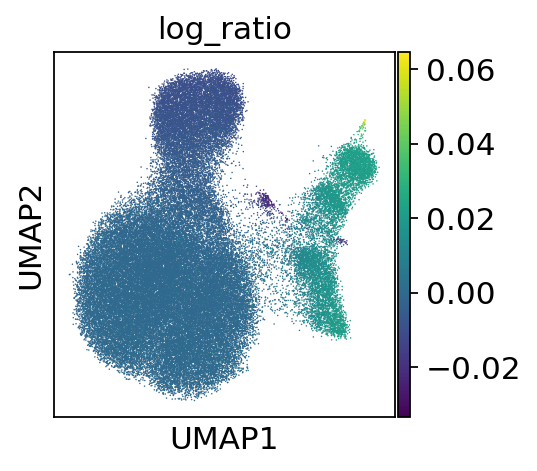

In [5]:
sc.pl.umap(adata, color="log_ratio")

In [6]:
is_abundant = np.logical_or(adata.obs.leiden=="1", adata.obs.leiden=="2").astype(int)
abs_ratio = np.abs(adata.obs["log_ratio"]).values
precision, recall, thresholds = precision_recall_curve(is_abundant,
                                                        abs_ratio
                                                        )

In [7]:
pr_auc = auc(recall, precision)

In [8]:
pr_auc

0.6296089117317438